**Imports**

In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# I set up the environment and load the cleaned data
project_root = os.path.abspath('..')
data_path = os.path.join(project_root, 'data', 'processed', 'world_bank_2019_cleaned.csv')
df = pd.read_csv(data_path)

**Building the Polynomial Feature**

In [2]:
# I create a new feature by squaring the life expectancy column
# This allows the linear model to fit a parabolic curve
df['life_expectancy_squared'] = df['life_expectancy'] ** 2

# I define my dependent variable with a log transformation
y = np.log(df['gdp_per_capita'])

# I define my new set of independent variables, including the squared term
X_poly = df.drop(columns=['country_code', 'country_name', 'gdp_per_capita'])
X_poly_with_constant = sm.add_constant(X_poly)

print("Polynomial feature engineered successfully.")

Polynomial feature engineered successfully.


**Rerunning the model**

In [3]:
# I fit the new OLS model with the polynomial term included
poly_model = sm.OLS(y, X_poly_with_constant).fit()

# I print the summary to see if the R-squared improved
print(poly_model.summary())

                            OLS Regression Results                            
Dep. Variable:         gdp_per_capita   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     113.3
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.15e-78
Time:                        17:53:49   Log-Likelihood:                -258.14
No. Observations:                 259   AIC:                             534.3
Df Residuals:                     250   BIC:                             566.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

**Checking new residuals**

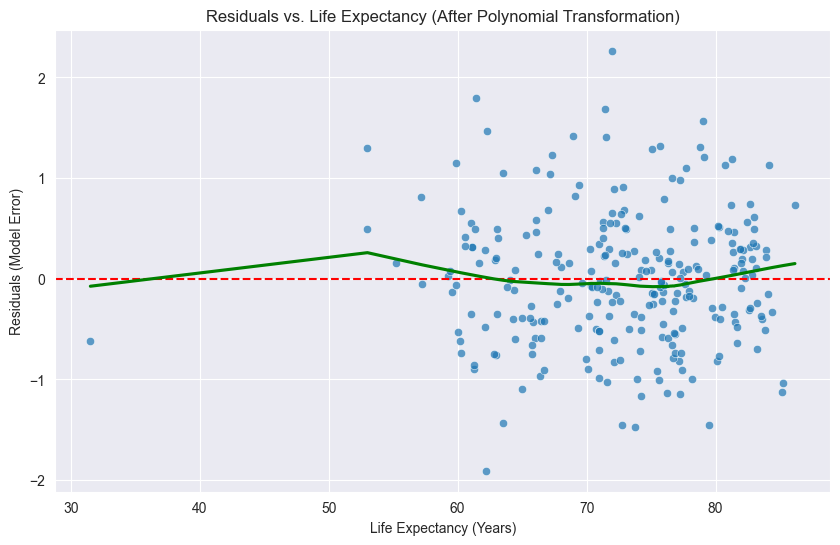

In [4]:
# I calculate the new residuals
poly_residuals = poly_model.resid

# I plot the new residuals to verify that the U-shape is gone
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['life_expectancy'], y=poly_residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
sns.regplot(x=df['life_expectancy'], y=poly_residuals, scatter=False, color='green', lowess=True)

plt.title('Residuals vs. Life Expectancy (After Polynomial Transformation)')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Residuals (Model Error)')
plt.show()

**Deriving the Final Equation**

In [5]:
# I extract the exact coefficients from the trained model
params = poly_model.params

print("Here is the derived macroeconomic equation:\n")
print("ln(GDP) = ")
print(f"  {params['const']:.4f}")
for feature in X_poly.columns:
    print(f"  + ({params[feature]:.4f} * {feature})")

Here is the derived macroeconomic equation:

ln(GDP) = 
  10.5494
  + (0.0001 * fdi_inflows)
  + (-0.0009 * inflation_rate)
  + (-0.0143 * capital_formation)
  + (0.0026 * trade_openness)
  + (0.0142 * labor_force_part)
  + (-0.2248 * life_expectancy)
  + (-0.1085 * population_growth)
  + (0.0026 * life_expectancy_squared)
